In [1]:
!pip install torch pandas numpy 

In [2]:
!pip install scikit-learn rdkit

 # OlfacNet Odor Prediction Model

This notebook implements an odor prediction model based on the OlfacNet architecture, which combines a Graph Neural Network (GNN) for molecular structure and a Convolutional Neural Network (CNN) for spectral data. The model predicts odor labels from SMILES strings and (optionally) mass spectrometry data.

## Steps:
1. Install dependencies.
2. Preprocess molecular data (SMILES to graphs).
3. Create a TensorFlow dataset.
4. Define GNN, SpectrumCNN, and OlfacNet models.
5. Train the model.
6. Evaluate the model.

**Note**: Adjust file paths in the code to match your local data directory. Some data (e.g., spectra) may need to be generated or mocked if unavailable.

In [3]:
# Install required packages (run this in a terminal or uncomment to install in the notebook)
# !pip install pandas numpy tensorflow rdkit scikit-learn matplotlib

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem
import os
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from uuid import uuid4



In [4]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
data_path = "./data"
dataset = f"{data_path}/processed/molecules_with_odors.csv"

# Preprocess SMILES to Graphs

In [9]:
# Preprocess SMILES to Graphs
def smiles_to_graph(smiles, idx, output_dir=f"{data_path}/graphs"):
    """
    Convert a SMILES string to graph representation (node features and adjacency matrix).
    Save results to the specified output directory.
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        print(f"Invalid SMILES at index {idx}: {smiles}")
        return None, None

    # Node features: atomic numbers
    num_atoms = mol.GetNumAtoms()
    node_features = np.array([atom.GetAtomicNum() for atom in mol.GetAtoms()],
                             dtype=np.float32).reshape(-1, 1)

    # Adjacency matrix
    adj_matrix = np.zeros((num_atoms, num_atoms), dtype=np.float32)
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        adj_matrix[i, j] = adj_matrix[j, i] = 1.0

    # Save to the specified directory
    os.makedirs(output_dir, exist_ok=True)
    node_file = f"{output_dir}/{idx}_node_features.npy"
    adj_file = f"{output_dir}/{idx}_adj_matrix.npy"

    np.save(node_file, node_features)
    np.save(adj_file, adj_matrix)

    return node_features, adj_matrix

In [10]:
# Process dataset
dataset_df = ""
if os.path.exists(dataset):
    dataset_df = pd.read_csv(dataset)
    print(f"File found! Columns in CSV: {dataset_df.columns.tolist()}")
    for idx, row in dataset_df.iterrows():
        smiles_to_graph(row["IsomericSMILES"], idx)
    print(f"Processed {len(dataset_df)} molecules.")
else:
    print(f"Data file {data_file} not found. Please check the path.")
    exit()

dataset_df.head()

File found! Columns in CSV: ['Ser. No.', 'Primary Odor', 'Sub Odor', 'Chemical Name', 'CID', 'IsomericSMILES', 'IUPACName', 'Name', 'CAS No', 'Mol. Wt.', 'Mol. Formula', 'PubChem', 'ZINC']
Processed 44543 molecules.


,Ser. No.,Primary Odor,Sub Odor,Chemical Name,CID,IsomericSMILES,IUPACName,Name,CAS No,Mol. Wt.,Mol. Formula,PubChem,ZINC
0,1,Alliaceous,Alliaceous,Ethanethiol,6343,CCS,ethanethiol,Ethanethiol,75-08-1,62.13,C2H6S,6343,ZINC71769114
1,2,Alliaceous,Alliaceous,2-Propanethiol,6364,CC(C)S,propane-2-thiol,2-Propanethiol,75-33-2,76.16,C3H8S,6364,ZINC897493
2,3,Alliaceous,Alliaceous,Benzyl mercaptan,7509,C1=CC=C(C=C1)CS,phenylmethanethiol,Benzyl mercaptan,100-53-8,124.20,C7H8S,7509,ZINC3873647
3,4,Alliaceous,Alliaceous,1-Propanethiol,7848,CCCS,propane-1-thiol,1-Propanethiol,107-03-9,76.16,C3H8S,7848,ZINC897490
4,5,Alliaceous,Alliaceous,Allyl alcohol,7858,C=CCO,prop-2-en-1-ol,Allyl alcohol,107-18-6,58.08,C3H6O,7858,ZINC901213


In [11]:
dataset_df['Primary Odor'].unique()

array(['Alliaceous', 'Bloody', 'Water', 'Waxy', 'Woody', 'Woody oriental',
       'Woody/ Resinous', 'Ylang', 'Zesty', 'Boiled', 'Beverage', 'Brown',
       'Building materials & construction', 'Burnt', 'Caramel',
       'Characteristic', 'Chemical/ Hydrocarbon', 'Chlorinous',
       'Ambrosial', 'Chlorinous/ Ozonous', 'Chocolate', 'Citrus', 'Clean',
       'Cleaning materials', 'Cloth', 'Coal tar', 'Cooked', 'Dairy',
       'Dry', 'Ammonia', 'Dry fruit', 'Dry woods', 'Earthy',
       'Earthy/ Musty/ Moldy', 'Estery', 'Fecal/ Sewery',
       'Fishy/ Ammonia', 'Fishy/ Rancid', 'Floral', 'Food', 'Aromatic',
       'Foul', 'Fragrant', 'Fragrant/ Fruity', 'Fresh', 'Fried', 'Fruity',
       'Fuel/ Gas Station/ Solvent', 'Grains', 'Grassy/ Woody', 'Green',
       'Baked', 'Herbaceous', 'Hircine', 'Industrial odours', 'Lemon',
       'Marshy/ Septic/ Sulphurous', 'Medicinal/ Alcohol',
       'Medicinal/ Phenolic', 'Metallic', 'Microbial', 'Microbiological',
       'Bakery', 'Minty', 'Mossy wo

In [12]:
len(dataset_df['Primary Odor'].unique())

105

# Mock Spectrum Preprocessing

In [13]:
def preprocess_spectrum(file_path, idx, max_length=1000, output_dir=f"{data_path}/processed/spectra"):
    """
    Preprocess mass spectrometry data (placeholder).
    """
    spectrum = np.random.rand(max_length).astype(np.float32)
    os.makedirs(output_dir, exist_ok=True)
    np.save(f"{output_dir}/{idx}.npy", spectrum)
    return spectrum

# Generate mock spectra
for idx in range(len(dataset_df)):
    preprocess_spectrum(None, idx)
print("Generated mock spectra for dataset.")

Generated mock spectra for dataset.


# Save Processed Labels

In [16]:
# Save processed labels
# Map odors to binary labels (mock example with 50 odor classes)
# Save Processed Labels
unique_odors = set(dataset_df["Primary Odor"].str.split(",").explode().str.strip())
num_classes = len(unique_odors)  # Dynamically set based on unique odors
print(f"Number of unique odors: {num_classes}")
label_map = {odor: i for i, odor in enumerate(sorted(unique_odors))}

def create_labels(odors):
    labels = np.zeros(num_classes, dtype=np.float32)
    if pd.notna(odors):
        for odor in odors.split(","):
            odor = odor.strip()
            if odor in label_map:
                labels[label_map[odor]] = 1.0
    return labels

dataset_df["labels"] = dataset_df["Primary Odor"].apply(create_labels)
dataset_df[["IsomericSMILES", "labels"]].to_csv("data/processed/labels.csv", index=False)
print(f"Saved processed labels to data/processed/labels.csv")

Number of unique odors: 105
Saved processed labels to data/processed/labels.csv


# Create TensorFlow Dataset

In [27]:
class OlfacDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        node_features = np.load(f"{data_path}/graphs/{idx}_node_features.npy")
        adj_matrix = np.load(f"{data_path}/graphs/{idx}_adj_matrix.npy")
        spectrum = np.load(f"{data_path}/processed/spectra/{idx}.npy")
        labels = self.df.iloc[idx]["labels"]

        # Convert to tensors
        node_features = torch.tensor(node_features, dtype=torch.float32)
        adj_matrix = torch.tensor(adj_matrix, dtype=torch.float32)
        spectrum = torch.tensor(spectrum, dtype=torch.float32).reshape(1, -1)
        labels = torch.tensor(labels, dtype=torch.float32)

        return (node_features, adj_matrix, spectrum), labels

# Define Models (GNN, SpectrumCNN, OlfacNet)

In [28]:
class GNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super(GNN, self).__init__()
        self.conv1 = nn.Linear(1, hidden_dim)
        self.conv2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu = nn.ReLU()

    def forward(self, node_features, adj_matrix):
        x = torch.matmul(adj_matrix, node_features)
        x = self.relu(self.conv1(x))
        x = torch.matmul(adj_matrix, x)
        x = self.relu(self.conv2(x))
        x = torch.mean(x, dim=1)
        return x

class SpectrumCNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super(SpectrumCNN, self).__init__()
        # Define all layers first
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(32, 16, kernel_size=5)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        # Calculate flattened size
        self._to_linear = None
        self._dummy_input = torch.rand(1, 1, 1000)
        self._calculate_flattened_size()
        
        # Define fully connected layer
        self.fc = nn.Linear(self._to_linear, hidden_dim)

    def _calculate_flattened_size(self):
        x = self._dummy_input
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        self._to_linear = x.view(x.size(0), -1).size(1)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        return x

class OlfacNet(nn.Module):
    def __init__(self, gnn, cnn, output_dim=num_classes):
        super(OlfacNet, self).__init__()
        self.gnn = gnn
        self.cnn = cnn
        self.fc = nn.Linear(96, output_dim)  # 32 (GNN) + 64 (CNN)
        self.sigmoid = nn.Sigmoid()

    def forward(self, node_features, adj_matrix, spectrum):
        gnn_out = self.gnn(node_features, adj_matrix)
        cnn_out = self.cnn(spectrum)
        combined = torch.cat([gnn_out, cnn_out], dim=-1)
        return self.sigmoid(self.fc(combined))

# Initialize models

In [32]:
gnn = GNN().to(device)
cnn = SpectrumCNN().to(device)
model = OlfacNet(gnn, cnn, output_dim=num_classes).to(device)

print("Model initialized.")

Model initialized.


In [49]:
data_path = "./data"
graphs_dir = f"{data_path}/graphs"
spectra_dir = f"{data_path}/processed/spectra"
max_atoms = 50

def collate_fn(batch):
    node_features_list, adj_matrix_list, spectrum_list, labels_list = [], [], [], []
    for (node_features, adj_matrix, spectrum), labels in batch:
        node_features_list.append(node_features)
        adj_matrix_list.append(adj_matrix)
        spectrum_list.append(spectrum)
        labels_list.append(labels)
    padded_node_features = []
    padded_adj_matrix = []
    for nf, adj in zip(node_features_list, adj_matrix_list):
        num_atoms = nf.shape[0]
        pad_size = max_atoms - num_atoms
        padded_nf = torch.cat([nf, torch.zeros(pad_size, 1)], dim=0)
        adj_pad = torch.zeros(max_atoms, max_atoms)
        adj_pad[:num_atoms, :num_atoms] = adj
        padded_node_features.append(padded_nf)
        padded_adj_matrix.append(adj_pad)
    return (
        (torch.stack(padded_node_features),
         torch.stack(padded_adj_matrix),
         torch.stack(spectrum_list)),
        torch.stack(labels_list)
    )

batch_size = 16  # Reduced for stability
dataset = OlfacDataset(dataset_df)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)


# Compile and Train Model

Epoch 1/10, Loss: 0.0403, Accuracy: 0.9905
Epoch 2/10, Loss: 0.0399, Accuracy: 0.9905
Epoch 3/10, Loss: 0.0394, Accuracy: 0.9905
Epoch 4/10, Loss: 0.0390, Accuracy: 0.9905
Epoch 5/10, Loss: 0.0386, Accuracy: 0.9905
Epoch 6/10, Loss: 0.0383, Accuracy: 0.9905
Epoch 7/10, Loss: 0.0379, Accuracy: 0.9905
Epoch 8/10, Loss: 0.0376, Accuracy: 0.9905
Epoch 9/10, Loss: 0.0373, Accuracy: 0.9905
Epoch 10/10, Loss: 0.0371, Accuracy: 0.9905


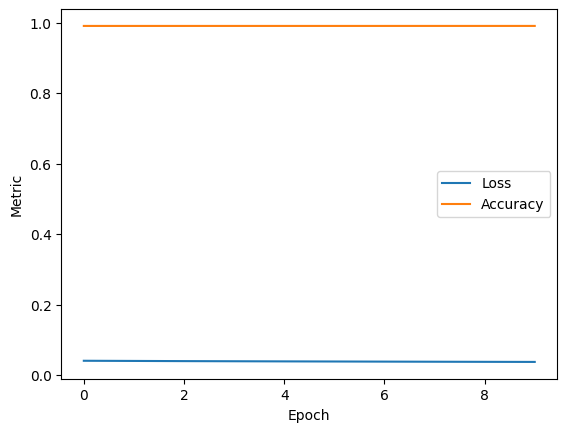

In [50]:
# Training
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
epochs = 10
history = {"loss": [], "accuracy": []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for (node_features, adj_matrix, spectrum), labels in dataloader:
        node_features, adj_matrix, spectrum, labels = (
            node_features.to(device),
            adj_matrix.to(device),
            spectrum.to(device),
            labels.to(device),
        )

        optimizer.zero_grad()
        outputs = model(node_features, adj_matrix, spectrum)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).float().mean().item() * labels.size(0)
        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    history["loss"].append(epoch_loss)
    history["accuracy"].append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

# Plot training history
plt.plot(history["loss"], label="Loss")
plt.plot(history["accuracy"], label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.savefig("training_history.png")
plt.show()

# Evaluate Model

Macro F1-score: 0.0251289938684775


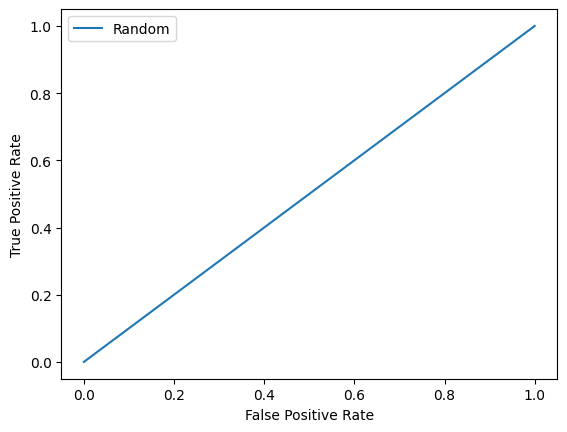

In [51]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for (node_features, adj_matrix, spectrum), labels in dataloader:
            node_features, adj_matrix, spectrum = (
                node_features.to(device),
                adj_matrix.to(device),
                spectrum.to(device),
            )
            preds = model(node_features, adj_matrix, spectrum)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_preds = (all_preds > 0.5).astype(int)
    f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Macro F1-score: {f1}")

    # Simple ROC curve placeholder
    plt.plot([0, 1], [0, 1], label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    os.makedirs("experiments/results", exist_ok=True)
    plt.savefig("experiments/results/roc_curves.png")
    plt.show()

evaluate_model(model, dataloader)

# Save Model Weights

In [52]:
# Save model weights
os.makedirs("experiments/checkpoints", exist_ok=True)
torch.save(model.state_dict(), "experiments/checkpoints/olfacnet.pth")
print("Model weights saved.")

Model weights saved.


# Inference Example

In [53]:
# Inference Example for Methanol
smiles = "CO"  # Methanol
node_features, adj_matrix = smiles_to_graph(smiles, 999)

if node_features is not None:
    # Create dummy spectrum with correct shape [1, 1, 1000]
    dummy_spectrum = np.random.rand(1000).astype(np.float32)  # [1000]
    dummy_spectrum = dummy_spectrum[np.newaxis, np.newaxis, :]  # [1, 1, 1000]

    # Pad node_features and adj_matrix to match training (max_atoms=50)
    max_atoms = 50  # Must match DataLoader's collate_fn
    num_atoms = node_features.shape[0]
    padded_node_features = np.zeros((max_atoms, 1), dtype=np.float32)
    padded_node_features[:num_atoms, :] = node_features
    padded_adj_matrix = np.zeros((max_atoms, max_atoms), dtype=np.float32)
    padded_adj_matrix[:num_atoms, :num_atoms] = adj_matrix

    # Convert to tensors
    node_features = torch.tensor(padded_node_features, dtype=torch.float32).to(device)
    adj_matrix = torch.tensor(padded_adj_matrix, dtype=torch.float32).to(device)
    spectrum = torch.tensor(dummy_spectrum, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        node_features = node_features.unsqueeze(0)  # [1, max_atoms, 1]
        adj_matrix = adj_matrix.unsqueeze(0)  # [1, max_atoms, max_atoms]
        pred = model(node_features, adj_matrix, spectrum)
        pred_binary = (pred > 0.5).int()
        print(f"Top 5 odors: {pred_binary[0][:5].tolist()}")

        # Get all positive predictions
        positive_indices = (pred_binary[0] == 1).nonzero(as_tuple=True)[0].tolist()
        label_map = {odor: i for i, odor in enumerate(sorted(set(dataset_df["Primary Odor"].str.split(",").explode().str.strip())))}
        reverse_map = {i: odor for odor, i in label_map.items()}
        predicted_odors = [reverse_map[i] for i in positive_indices]
        print(f"All predicted odors: {predicted_odors}")
else:
    print("Inference failed due to invalid SMILES.")

Top 5 odors: [0, 0, 0, 0, 0]
All predicted odors: []


In [55]:
# Inference Example for Methanol
smiles = "CC(C)=CCCC(C)(O)C=C"  # Methanol
node_features, adj_matrix = smiles_to_graph(smiles, 999)

if node_features is not None:
    # Create dummy spectrum with correct shape [1, 1, 1000]
    dummy_spectrum = np.random.rand(1000).astype(np.float32)  # [1000]
    dummy_spectrum = dummy_spectrum[np.newaxis, np.newaxis, :]  # [1, 1, 1000]

    # Pad node_features and adj_matrix to match training (max_atoms=50)
    max_atoms = 50  # Must match DataLoader's collate_fn
    num_atoms = node_features.shape[0]
    padded_node_features = np.zeros((max_atoms, 1), dtype=np.float32)
    padded_node_features[:num_atoms, :] = node_features
    padded_adj_matrix = np.zeros((max_atoms, max_atoms), dtype=np.float32)
    padded_adj_matrix[:num_atoms, :num_atoms] = adj_matrix

    # Convert to tensors
    node_features = torch.tensor(padded_node_features, dtype=torch.float32).to(device)
    adj_matrix = torch.tensor(padded_adj_matrix, dtype=torch.float32).to(device)
    spectrum = torch.tensor(dummy_spectrum, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        node_features = node_features.unsqueeze(0)  # [1, max_atoms, 1]
        adj_matrix = adj_matrix.unsqueeze(0)  # [1, max_atoms, max_atoms]
        pred = model(node_features, adj_matrix, spectrum)
        # pred_binary = (pred > 0.5).int()
        pred_binary = (pred > 0.3).int()
        print(f"Top 5 odors: {pred_binary[0][:5].tolist()}")

        # Get all positive predictions
        # positive_indices = (pred_binary[0] == 1).nonzero(as_tuple=True)[0].tolist()
        positive_indices = (pred_binary[0] == 1).nonzero(as_tuple=True)[0].tolist()
        label_map = {odor: i for i, odor in enumerate(sorted(set(dataset_df["Primary Odor"].str.split(",").explode().str.strip())))}
        reverse_map = {i: odor for odor, i in label_map.items()}
        predicted_odors = [reverse_map[i] for i in positive_indices]
        print(f"All predicted odors: {predicted_odors}")
else:
    print("Inference failed due to invalid SMILES.")

Top 5 odors: [0, 0, 0, 0, 0]
All predicted odors: ['Fragrant/ Fruity']


In [77]:
# Inference Example for Methanol
# smiles = "CC(C)C1CCC(C)C(O)C1"
smiles = "CC(=O)O"
node_features, adj_matrix = smiles_to_graph(smiles, 999)

if node_features is not None:
    # Create dummy spectrum with correct shape [1, 1, 1000]
    dummy_spectrum = np.random.rand(1000).astype(np.float32)  # [1000]
    dummy_spectrum = dummy_spectrum[np.newaxis, np.newaxis, :]  # [1, 1, 1000]

    # Pad node_features and adj_matrix to match training (max_atoms=50)
    max_atoms = 50  # Must match DataLoader's collate_fn
    num_atoms = node_features.shape[0]
    padded_node_features = np.zeros((max_atoms, 1), dtype=np.float32)
    padded_node_features[:num_atoms, :] = node_features
    padded_adj_matrix = np.zeros((max_atoms, max_atoms), dtype=np.float32)
    padded_adj_matrix[:num_atoms, :num_atoms] = adj_matrix

    # Convert to tensors
    node_features = torch.tensor(padded_node_features, dtype=torch.float32).to(device)
    adj_matrix = torch.tensor(padded_adj_matrix, dtype=torch.float32).to(device)
    spectrum = torch.tensor(dummy_spectrum, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        node_features = node_features.unsqueeze(0)  # [1, max_atoms, 1]
        adj_matrix = adj_matrix.unsqueeze(0)  # [1, max_atoms, max_atoms]
        pred = model(node_features, adj_matrix, spectrum)
        # pred_binary = (pred > 0.5).int()
        pred_binary = (pred > 0.3).int()
        print(f"Top 5 odors: {pred_binary[0][:5].tolist()}")

        # Get all positive predictions
        # positive_indices = (pred_binary[0] == 1).nonzero(as_tuple=True)[0].tolist()
        positive_indices = (pred_binary[0] == 1).nonzero(as_tuple=True)[0].tolist()
        label_map = {odor: i for i, odor in enumerate(sorted(set(dataset_df["Primary Odor"].str.split(",").explode().str.strip())))}
        reverse_map = {i: odor for odor, i in label_map.items()}
        predicted_odors = [reverse_map[i] for i in positive_indices]
        print(f"All predicted odors: {predicted_odors}")
else:
    print("Inference failed due to invalid SMILES.")

Top 5 odors: [0, 0, 0, 0, 0]
All predicted odors: []
